# RAPID-MFA-7b: Recycling rate increases gradually

## Descriptions
This module shows how to implement material recycling in a dynamic MFA. We illustrate this with the example of steel. In this scenario outflow recycling starts in 2005 at 0% and reaches 70% by 2040. This means that a changing share of the generated outflows are 'recovered' and can be used as input for inflows. In our model this inflow of recycled material directly replaces a part of the virgin inflows. While this is not the case in our example, you may encounter situations in which the recycling flow is larger than the required inflow. In this case all virgin inflows can be replaced with recycled material and there is still recycled material left over. This 'overflow' is accounted for in a separate column, see [Section 4](#4-scenario-b).

The model takes three inputs:
- A _stocks_ time series of steel
- A _survival curve_ describing the survival/depreciation of inflow cohorts in the stocks as time goes by
- A _recycling rate_ that specifies the share of the outflows that is recycled

It produces two model outputs:
- The _recycling flows_ time series
- The _virgin inflows_ time series
- The _recycling overflow_ time series


### Exogenous variables
__Stocks:__ Stocks data comes from https://doi.org/10.3390/resources7010009 converted to material stocks. 

__Survival curve:__ Weibull distribution, $shape=2.4$, $scale=16.9$, e.g. using `scipy.stats.weibull_min.sf(range(0, len(input_data)), c = 2.428914875, loc = 0, scale = 16.93851375)` Data from https://doi.org/10.3390/resources7010009

### Notes
1. The input data is intended to be replaced with your own data, for example imported from an Excel or CSV file. It should be in an array-like format of any length.
2. The model is split into separate code blocks for ease of understanding. The code blocks can be merged to run as a complete model.

### Relations with other RAPID-MFA codes
- This model builds on the basic `RAPID-MFA-2: The stock driven model`.
- `RAPID-MFA-5: library of survival functions`: The code below uses the Weibull lifetime distribution. The shape and scale parameters were adapted to the literature source.

## Version, licence, and how to cite
This notebook is <a href="https://creativecommons.org/licenses/by-nc/4.0"><img src="https://mirrors.creativecommons.org/presskit/buttons/88x31/png/by-nc.png" alt="CC-BY-NC" width="70"> CC-BY-NC</a>, meaning you can - and should! - freely reuse and adapt this code for noncommercial purposes __as long as you attribute this source__. 




## 1. Load libraries

In [14]:
import numpy as np
import pandas as pd
import scipy.stats
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Define example input data

In [15]:
# %% 2. Define example input data
# timeframe, stock data represents stock of cars
input_data = pd.Series([0.00000000e+00, 1.79555811e+04, 9.89352520e+06, 3.13050276e+07,
                        6.92990372e+07, 1.19345467e+08, 2.07709106e+08, 4.28015637e+08,
                        6.92482335e+08, 1.05920396e+09, 1.38068174e+09, 1.67317604e+09,
                        1.93955342e+09, 2.20988526e+09, 2.67975852e+09, 3.24683697e+09,
                        3.76840435e+09, 4.44364299e+09, 5.22389010e+09, 6.12383016e+09,
                        7.15928839e+09, 8.34696452e+09, 9.70408959e+09, 1.12478988e+10,
                        1.29949758e+10, 1.49605036e+10, 1.71573774e+10, 1.95953123e+10,
                        2.22799484e+10, 2.52121043e+10, 2.83871580e+10, 3.17947471e+10,
                        3.54187188e+10, 3.92374590e+10, 4.32244525e+10, 4.73492001e+10,
                        5.15781820e+10, 5.58760204e+10, 6.02066098e+10, 6.45341816e+10,
                        6.88242801e+10, 7.30445662e+10, 7.71654566e+10, 8.11606367e+10,
                        8.50073507e+10, 8.86865992e+10, 9.21831751e+10, 9.54856131e+10,
                        9.85860339e+10, 1.01479931e+11, 1.04165883e+11, 1.06645262e+11,
                        1.08921855e+11],
                       name = 'stocks', 
                       index = [1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008,
                                2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
                                2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030,
                                2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041,
                                2042, 2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050])

# define the lifetime parameters
ages = range(0, len(input_data))  # the maximum age in the MFA model is equal to the length of the input data
shape = 2.428914875
scale = 16.93851375

# create the survival curve
survival_curve = scipy.stats.weibull_min.sf(ages, c = shape, loc = 0, scale = scale)

## 3. Set up the MFA system

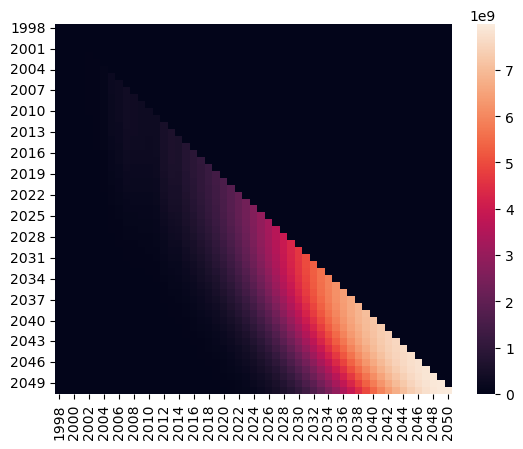

In [16]:
# define the units of the system, with separate units for the products layer (vehicles in number of units) and the materials layer (in mass)
units = {'time_interval': 'year', 
         'material_flows': 'kg/year',
         'material_stocks': 'kg'
         }

timeframes = cohorts = input_data.index  # timeframes are the "snapshots" of the system in every time interval, while cohorts are the inflows that enter the system in every time interval. They are the same because we have one inflow per time interval.

# defines the step size of our model, in this case 1 year (see time_interval in 'units' above)
time_interval = 1

# determines the last year of the model
cohort_stop = (cohorts[-1] + time_interval)  # because of exclusive slicing in python, an extra time interval is required

# create survival curve matrix filled with zeros
survival_curves_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# and populate that matrix
for cohort in cohorts:
    cohort
    # at each iteration, we shift the survival curve and we fill the survival curve matrix with the shifted survival curve
    survival_curves_matrix.loc[cohort: , cohort] = survival_curve[0 : cohort_stop - cohort]

# create cohorts survival matrix and calculate the inflows

# initialize the cohort_survival_matrix filled with zeros
cohorts_survival_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# create the empty DataFrame for the baseline model
steel_baseline = pd.DataFrame(index = timeframes, columns = ['stocks', 
                                                         'inflows', 
                                                         'outflows', 
                                                         'stock_changes'])
# add the previously defined stocks
steel_baseline['stocks'] = input_data

# Populate the DataFrame
for cohort in cohorts:
    # calculate the inflow of the time-th year
    steel_baseline.loc[cohort, 'inflows'] = (
        steel_baseline.loc[cohort, 'stocks'] - cohorts_survival_matrix.loc[cohort, : cohort - 1].sum()
    ) / survival_curves_matrix.loc[cohort, cohort]
    # now that the time-th inflow is known, scale the shifted survival curve with this inflow
    cohorts_survival_matrix.loc[:, cohort] = survival_curves_matrix.loc[:, cohort] * steel_baseline.loc[cohort, 'inflows']
    
# and visualize the cohort_survival_matrix matrix with a heatmap
sns.heatmap(cohorts_survival_matrix, annot=False)

# calculate stock changes (net change to stock)
# prepend=0 replicates the convention that stock_change is the difference between current timeframe and previous timeframe. 
steel_baseline["stock_changes"] = np.diff(steel_baseline["stocks"], prepend=0)

# calculate outflows using mass balance
steel_baseline["outflows"] = steel_baseline["inflows"] - steel_baseline["stock_changes"]

## 4. Scenario B
Steel recycling increases linearly from 0% in 2005 to 70% in 2040.

In [17]:
# copy the baseline scenario to have a unique dataframe per scenario
steel_recyclingB = steel_baseline.copy()

# define recycling rates
recycling_rate_Fe_2005 = 0
recycling_rate_Fe_2040 = 0.7
# interpolate linearly between 2005 and 2040
recycling_rate_Fe_timeseries = np.interp(steel_recyclingB.index, [2005, 2040], [recycling_rate_Fe_2005, recycling_rate_Fe_2040])

# calculate recycling flows
steel_recyclingB['recycling flows'] = steel_recyclingB['outflows'] * recycling_rate_Fe_timeseries

In [18]:
# If all recycled material is put into use in the same year, then mass balance: inflow = recycled material + virgin material. 
# But if there's more recycled material than inflow demand, then we would end up with negative virgin inflows.
# To address this, we create an 'overflow' column. In cases where recycling flows is larger than inflows it will only replace
# the inflows and any left over 'material' will be added to the 'overflow' column

# determine the virgin inflow under consideration of the available recycled material. If inflows are greater than the recycled material flow
# then the subtraction results in the required virgin material. If the recycled material is greater than the required inflow material, then
# zero viring inflows are required.
steel_recyclingB['virgin inflows'] = np.where(steel_recyclingB['inflows'] - steel_recyclingB['recycling flows'] > 0, 
                                              steel_recyclingB['inflows'] - steel_recyclingB['recycling flows'], 0)

# determine the recycled overflow similarly to how the virgin inflow was determined. If recycled material outweighs the inflows, then we take
# the absolute difference, as this is the 'overflow', and add it to the 'overflow' column.
steel_recyclingB['recycling overflow'] = np.where(steel_recyclingB['inflows'] - steel_recyclingB['recycling flows'] < 0, 
                                                  abs(steel_recyclingB['inflows'] - steel_recyclingB['recycling flows']), 0)                                           

## 5. Compare MFA results

<Axes: title={'center': 'Cumulative virgin materials avoided'}, ylabel='kg'>

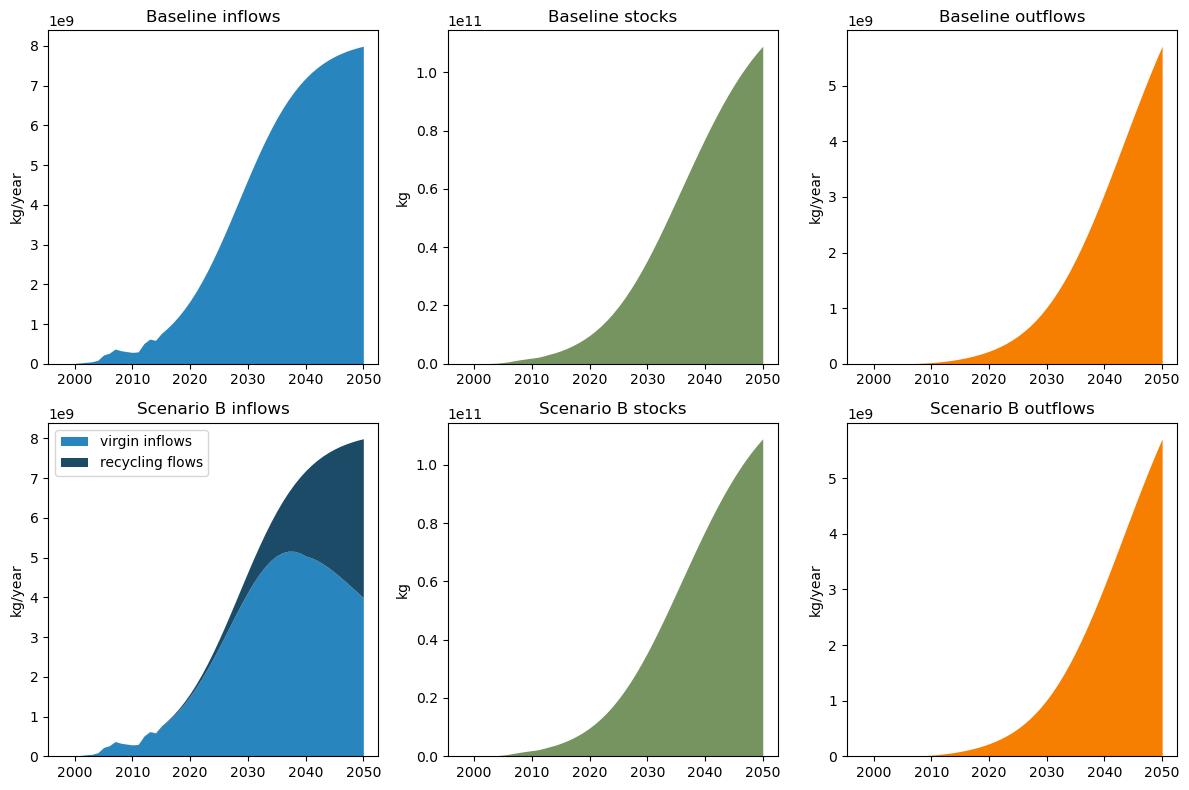

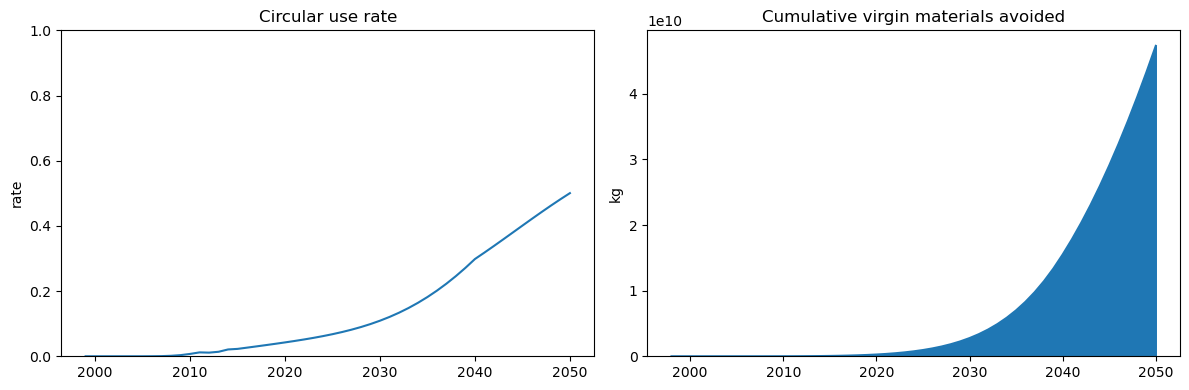

In [19]:
# visualize the inflows, outflows, and stocks results for the baseline and scenario B
results_fig, results_ax = plt.subplots(nrows=2, ncols=3, figsize=(12, 8), tight_layout=True)
steel_baseline.loc[:, 'inflows'].plot(ylabel=units['material_flows'],
                                      kind='area',
                                      color=["#2985BD"],
                                      ax=results_ax[0, 0],
                                      linewidth = 0,
                                      title = 'Baseline inflows'
                                      )
steel_baseline.loc[:, 'stocks'].plot(ylabel=units['material_stocks'],
                                     kind='area',
                                     color=["#759460"],
                                     ax=results_ax[0, 1],
                                     linewidth = 0,
                                     title = 'Baseline stocks'
                                     )
steel_baseline.loc[:, 'outflows'].plot(ylabel=units['material_flows'],
                                       kind='area',
                                       color=["#F67E00"],
                                       ax=results_ax[0, 2],
                                       linewidth = 0,
                                       title = 'Baseline outflows'
                                       )

steel_recyclingB.loc[:, ['virgin inflows', 'recycling flows']].plot(ylabel=units['material_flows'],
                                      kind='area',
                                      color=["#2985BD", "#1C4B68"],
                                      ax=results_ax[1, 0],
                                      linewidth = 0,
                                      title = 'Scenario B inflows'
                                      )
steel_recyclingB.loc[:, 'stocks'].plot(ylabel=units['material_stocks'],
                                     kind='area',
                                     color=["#759460", "#567840"],
                                     ax=results_ax[1, 1],
                                     linewidth = 0,
                                     title = 'Scenario B stocks'
                                     )
steel_recyclingB.loc[:, 'outflows'].plot(ylabel=units['material_flows'],
                                       kind='area',
                                       color=["#F67E00", "#AC6010"],
                                       ax=results_ax[1, 2],
                                       linewidth = 0,
                                       title = 'Scenario B outflows'
                                       )

# plotting the ratio of recycled material in the inflow
results_fig2, results_ax2 = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), tight_layout=True)
(steel_recyclingB.loc[:, 'recycling flows'] / steel_recyclingB.loc[:, 'inflows']).plot(ylabel='rate',
                                                                                       ax=results_ax2[0],
                                                                                       ylim=(0, 1),
                                                                                       title='Circular use rate'
                                                                                       )

steel_recyclingB.loc[:, 'recycling flows'].cumsum().plot(ylabel='kg',
                                                         kind='area',
                                                         ax=results_ax2[1],
                                                         title='Cumulative virgin materials avoided'
                                                         )